# Regressió

## Llibreries

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

## Càrrega de dades

El dataset tips (disponible directament des de seaborn) recull comptes de restaurant i la propina (tip) que deixa cada client.

Té 244 files que **combinen features numèriques** (`total_bill`, `size`) **amb features categòriques** (`sex`, `smoker`, `day`, `time`) — així que, com un dataset real, necessita preprocessament abans de poder alimentar una xarxa neuronal.

És una tasca de **regressió**: predim el target continu `tip` (l'import de la propina, en dòlars).

In [21]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [22]:
df.shape

(244, 7)

El target `tip` és continu — una ullada ràpida a la seva distribució:

In [23]:
df['tip'].describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

Missing values (tips no en té cap, però sempre s'ha de comprovar — de totes maneres el pipeline els tracta):

In [24]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Split de dades

Predim `tip` a partir de la resta de columnes: numèriques (`total_bill`, `size`) i categòriques (`sex`, `smoker`, `day`, `time`).

Aquí no fem stratify — el target és continu.

In [25]:
# Grups de features (es fan servir tant per al split com per al pipeline de preprocessament)
features_num = ['total_bill', 'size']
features_cat = ['sex', 'smoker', 'day', 'time']

X = df[features_num + features_cat]
y = df['tip']

# Split Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split Train / Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

## Feature engineering

Una xarxa neuronal necessita entrades **numèriques, escalades i completes**. Construïm un `ColumnTransformer` que tracta cada tipus de columna de manera diferent:

- **numèriques** (`total_bill`, `size`) → imputa els missing values amb la mediana i després estandarditza (mitjana 0, std 1)
- **categòriques** (`sex`, `smoker`, `day`, `time`) → imputa els missing values amb la categoria més freqüent i després aplica **one-hot encoding**

Embolcallar-ho tot dins d'un `Pipeline` ens permet **fer el fit només amb les dades de train** i reutilitzar exactament la mateixa transformació sobre validation i test — cosa que evita el data leakage. Com que ara l'escalat es fa aquí, ja no necessitem cap capa `Normalization` de Keras al model.

In [26]:
# Un sub-pipeline per cada tipus de columna
numeric = Pipeline([
    ('impute', SimpleImputer(strategy='median')),      # omple els missing numèrics
    ('scale', StandardScaler()),                       # mitjana 0, std 1
])

categorical = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),                   # omple les categories missing
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),  # one-hot encoding (sortida densa)
])

# Envia cada grup de columnes al seu sub-pipeline
preprocessor = ColumnTransformer([
    ('num', numeric, features_num),
    ('cat', categorical, features_cat),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
# Fem el fit NOMÉS amb les dades de train i després apliquem la mateixa transformació a cada split (sense leakage)
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

X_train_p.shape

(156, 12)

In [28]:
# Noms de les features després de la transformació (primer les numèriques, després les categories expandides amb one-hot)
preprocessor.get_feature_names_out()

array(['num__total_bill', 'num__size', 'cat__sex_Female', 'cat__sex_Male',
       'cat__smoker_No', 'cat__smoker_Yes', 'cat__day_Fri',
       'cat__day_Sat', 'cat__day_Sun', 'cat__day_Thur',
       'cat__time_Dinner', 'cat__time_Lunch'], dtype=object)

## Modelatge

In [29]:
# Definim el model de NN (l'entrada ja ve escalada + one-hot encoded pel pipeline)

model = Sequential([
    Input((X_train_p.shape[1],)),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear'),
])

model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss='mae',
    metrics=[RootMeanSquaredError()]
)

In [30]:
results = model.fit(X_train_p, y_train, validation_data=(X_val_p, y_val), epochs=100, batch_size=32)

Epoch 1/100


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 2.7996 - root_mean_squared_error: 3.0978 - val_loss: 2.1775 - val_root_mean_squared_error: 2.4830
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.3189 - root_mean_squared_error: 2.6560 - val_loss: 1.6023 - val_root_mean_squared_error: 1.9489
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7261 - root_mean_squared_error: 2.1144 - val_loss: 0.9517 - val_root_mean_squared_error: 1.3057
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.1853 - root_mean_squared_error: 1.5041 - val_loss: 0.8422 - val_root_mean_squared_error: 1.1033
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9990 - root_mean_squared_error: 1.2672 - val_loss: 1.0335 - val_root_mean_squared_error: 1.3326
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0374 - root_mean_squared_error: 1.3297 - val_loss: 0.9098 - val_root_mean_squared_error: 1.1297
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9078 - root_mean_squar

In [31]:
# L'objecte `results` conté els valors de loss i mètriques de les dades de train

results.history.keys()

dict_keys(['loss', 'root_mean_squared_error', 'val_loss', 'val_root_mean_squared_error'])

In [32]:
# Últims 5 valors de MAE de les dades de train

results.history['loss'][-5:]

[0.4930973947048187,
 0.4941611588001251,
 0.4903543293476105,
 0.4852393567562103,
 0.47946447134017944]

Compte amb l'overfitting!

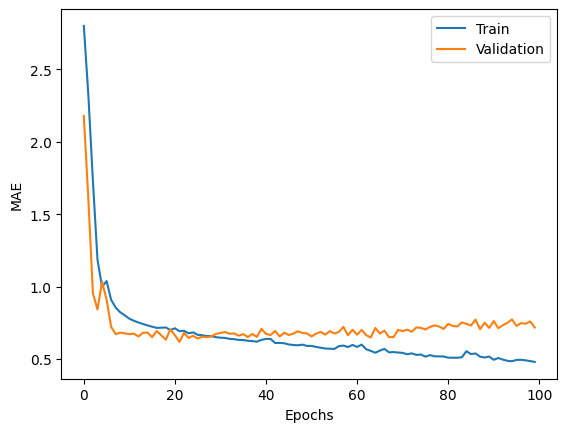

In [33]:
# Visualitza el MAE d'entrenament al llarg de les epochs

plt.plot(results.history['loss'], label='Train')
plt.plot(results.history['val_loss'], label='Validation')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.show()

In [34]:
# Avalua amb les mètriques indicades (quan vam compilar el model) i la funció de loss

train_loss, train_rmse = model.evaluate(X_train_p, y_train, verbose=0)
val_loss, val_rmse = model.evaluate(X_val_p, y_val, verbose=0)

print(f'Train MAE: {train_loss:.2f}')
print(f'Validation MAE: {val_loss:.2f}')

Train MAE: 0.50
Validation MAE: 0.72


## Avaluació sobre test

In [35]:
# Avaluem test després de l'entrenament

test_loss, test_rmse = model.evaluate(X_test_p, y_test, verbose=0)
print(f'Test MAE: {test_loss:.2f}')

Test MAE: 0.84


In [36]:
# Si vols obtenir les prediccions, fes servir la funció `predict`

y_test_preds = model.predict(X_test_p, verbose=0)
y_test_preds

array([[3.82074  ],
       [2.1032188],
       [4.3231483],
       [2.7448773],
       [1.9547619],
       [4.057359 ],
       [4.1210456],
       [1.6191435],
       [2.5194507],
       [3.2396882],
       [2.9300544],
       [1.6686327],
       [1.4944643],
       [3.7562277],
       [1.6986613],
       [3.1757345],
       [2.9354913],
       [3.7017882],
       [2.3288906],
       [6.8608227],
       [3.0863593],
       [3.1037705],
       [2.1724703],
       [1.5752054],
       [3.6614516],
       [1.888976 ],
       [2.232804 ],
       [3.1168382],
       [2.7303112],
       [9.019905 ],
       [4.4749365],
       [1.7799908],
       [2.4823043],
       [2.713798 ],
       [2.2932358],
       [4.1723433],
       [2.18667  ],
       [6.105359 ],
       [1.6790332],
       [2.8102784],
       [1.6449286],
       [1.8634993],
       [3.9796638],
       [1.9771692],
       [1.7518338],
       [2.2410257],
       [1.9299341],
       [2.6669831],
       [1.8054479]], dtype=float32)

# Atenció

Tornar a executar `model.fit` continuarà amb els pesos (weights) del fit anterior!

Si vols reiniciar el model, has de sobreescriure la variable `model`.

In [37]:
# Ho veus? Ja obtenim un bon rendiment des del principi

model.fit(X_train_p, y_train, validation_data=(X_val_p, y_val), epochs=10, batch_size=32)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4928 - root_mean_squared_error: 0.8209 - val_loss: 0.7665 - val_root_mean_squared_error: 1.0000
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5010 - root_mean_squared_error: 0.8063 - val_loss: 0.7349 - val_root_mean_squared_error: 0.9391
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4948 - root_mean_squared_error: 0.8182 - val_loss: 0.7858 - val_root_mean_squared_error: 1.0029
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4922 - root_mean_squared_error: 0.8122 - val_loss: 0.7357 - val_root_mean_squared_error: 0.9403
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4893 - root_mean_squared_error: 0.8061 - val_loss: 0.7431 - val_root_mean_squared_error: 0.9773
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5031 - root_mean_squared_error: 0.8046 - val_loss: 0.7191 - val_root_mean_squared_error: 0.9363
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4745 - root_mean_